In [1]:

#Projet portfolio - E-commerce Olist
#Etape 3a : Segmentation clients RFM + clustering KMeans


#RFM = Recence, Frequence, Montant
    #- Recence  : nb de jours depuis le dernier achat du client
   # - Frequence: nb de commandes distinctes du client
   # - Montant  : total depense par le client


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("olist_dataset_analytique.csv", parse_dates=[
    "order_purchase_timestamp"
])
df_livre = df[df["order_status"] == "delivered"].copy()

In [4]:
# 1. Calcul des indicateurs RFM par client

date_reference = df_livre["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    df_livre.groupby("customer_unique_id")
    .agg(
        recence=("order_purchase_timestamp", lambda x: (date_reference - x.max()).days),
        frequence=("order_id", "nunique"),
        montant=("prix_total", "sum"),
    )
    .reset_index()
)

In [5]:
# 2. Standardisation (necessaire avant KMeans, sensible aux echelles)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["recence", "frequence", "montant"]])

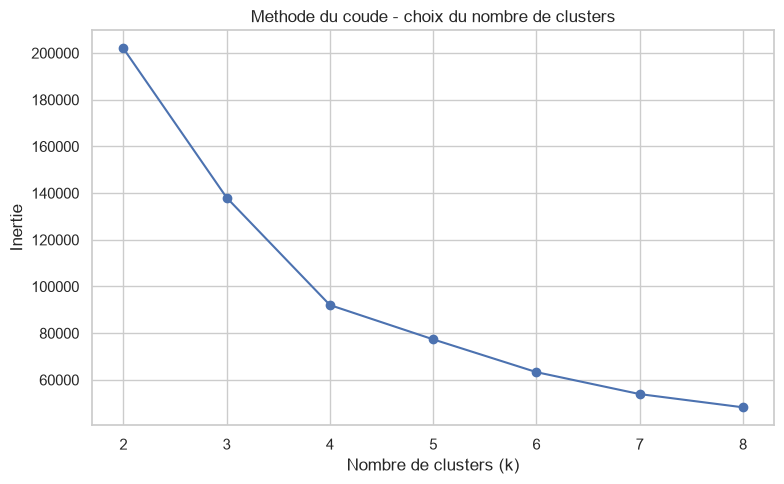

In [6]:
# 3. Choix du nombre de clusters (methode du coude)

inertion = []
range_k = range(2, 9)
for k in range_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertion.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(range_k), inertion, marker="o")
plt.title("Methode du coude - choix du nombre de clusters")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.tight_layout()
plt.savefig("kpi5_methode_coude.png", dpi=150)
plt.show()

# -> Regarder le graphe et choisir k au niveau du "coude"
# (souvent k=4 pour une segmentation RFM classique : on part sur 4 ici,
#  a ajuster selon ce que montre TON graphe)

In [7]:
# 4. Clustering final

K_CHOISI = 4

kmeans_final = KMeans(n_clusters=K_CHOISI, random_state=42, n_init=10)
rfm["cluster"] = kmeans_final.fit_predict(rfm_scaled)

# ----------------------------------------------------------------------
# 5. Profil moyen de chaque cluster (pour les nommer et les interpreter)
# ----------------------------------------------------------------------
profil_clusters = rfm.groupby("cluster")[["recence", "frequence", "montant"]].mean().round(1)
profil_clusters["nb_clients"] = rfm["cluster"].value_counts().sort_index()
profil_clusters

# Interpretation typique (a adapter selon TES chiffres) :
#   - recence basse + frequence/montant eleves  -> "Clients fideles / champions"
#   - recence elevee + frequence/montant faibles -> "Clients perdus / a relancer"
#   - recence basse + frequence/montant faibles  -> "Nouveaux clients"
#   - recence elevee + montant eleve             -> "Gros clients endormis, a reactiver"

,recence,frequence,montant,nb_clients
cluster,,,,
0,128.1,1.0,113.4,50746
1,387.3,1.0,114.0,37649
2,237.7,1.0,1142.0,2189
3,220.4,2.1,243.2,2774


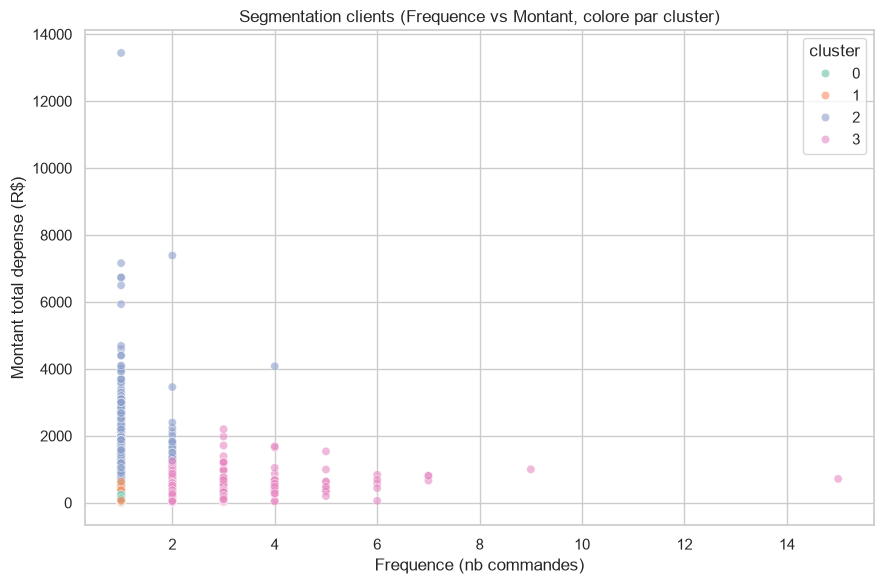

In [8]:
# 6. Visualisation des clusters

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfm, x="frequence", y="montant", hue="cluster", palette="Set2", alpha=0.6
)
plt.title("Segmentation clients (Frequence vs Montant, colore par cluster)")
plt.xlabel("Frequence (nb commandes)")
plt.ylabel("Montant total depense (R$)")
plt.tight_layout()
plt.savefig("kpi6_clusters_rfm.png", dpi=150)

In [9]:
# 7. Export pour reprise dans le notebook de synthese

rfm.to_csv("clients_rfm_segmentes.csv", index=False)